<a href="https://colab.research.google.com/github/duttaaritra794-design/ARITRA_DUTTA/blob/main/Autonomous_Wrehouse_Robot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BEST RL POLICY
Speed            = 2.00 m/s
Route Efficiency = 1.10
Safety Margin    = 2.00
Battery Usage    = 0.50
Efficiency = 130.00
Reward     = 13047.50


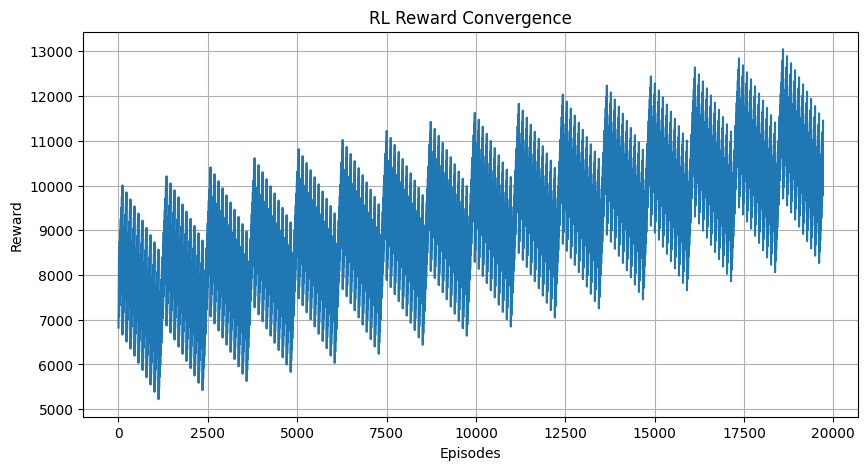

In [18]:
import numpy as np
import matplotlib.pyplot as plt

episodes = []
rewards = []

def calculateEfficiency(speed, route_efficiency, safety_margin, battery_usage):

    efficiency = (
    50
    + 20 * speed
    + 25 * route_efficiency
    + 10 * safety_margin
    - 15 * battery_usage
  )

    return efficiency

    #reward calculation

def calculateReward(eff, speed, safety_margin, battery_usage):

    delivery_reward = 100 * eff

    battery_penalty = -50 * (battery_usage ** 2)

    collision_penalty = -80 * ((2 - safety_margin) ** 2)

    speed_reward = 30 * speed

    reward = (
    delivery_reward
    + speed_reward
    + battery_penalty
    + collision_penalty
    )

    return reward

 # outside function

best_reward=-9999
best_policy=None
best_efficiency=None
episode=0

for speed in np.arange(0.5, 2.1, 0.1):

    for battery_usage in np.arange(0.5, 1.6, 0.1):

        for route_efficiency in np.arange(0.5, 1.1, 0.1):

            for safety_margin in np.arange(0.5, 2.1, 0.1):

                episode += 1

                efficiency = calculateEfficiency(
                    speed,
                    route_efficiency,
                    safety_margin,
                    battery_usage
                )

                reward = calculateReward(
                    efficiency,
                    speed,
                    safety_margin,
                    battery_usage
                )

                episodes.append(episode)
                rewards.append(reward)


                if reward > best_reward:

                    best_reward = reward

                    best_policy = (
                        speed,
                        route_efficiency,
                        safety_margin,
                        battery_usage
                    )

                    best_efficiency = efficiency

# ==========================================
# RESULTS
# ==========================================

print("===================================")
print("BEST RL POLICY")
print("===================================")

print(f"Speed            = {best_policy[0]:.2f} m/s")
print(f"Route Efficiency = {best_policy[1]:.2f}")
print(f"Safety Margin    = {best_policy[2]:.2f}")
print(f"Battery Usage    = {best_policy[3]:.2f}")

print("===================================")

print(f"Efficiency = {best_efficiency:.2f}")
print(f"Reward     = {best_reward:.2f}")

print("===================================")

# ==========================================
# GRAPH 1
# REWARD CONVERGENCE
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(episodes, rewards)

plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("RL Reward Convergence")

plt.grid(True)

plt.show()











